# Visual Search Engine using CLIP Embeddings.

## Imports

In [15]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from PIL import Image
import requests
import torch
from transformers import CLIPProcessor, CLIPModel
import faiss
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Dataset: Flickr8K
* The Flickr8k dataset consists of 8,000 images, each paired with five descriptive captions, making it a widely used benchmark for image captioning and vision-language tasks.
* The images cover diverse everyday scenes, including people, animals, and objects, providing a rich dataset for training and evaluating models that connect visual content with natural language.
* https://www.kaggle.com/datasets/adityajn105/flickr8k

In [8]:
dataset = pd.read_csv("flickr8k/captions.txt")
print("Shape of dataset:",dataset.shape)
dataset.head()

Shape of dataset: (40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [7]:
print("Number of unique images:", dataset['image'].nunique())
print("Number of unique captions:", dataset['caption'].nunique())

Number of unique images: 8091
Number of unique captions: 40201


### Samples

Caption: Several off-road vehicles are driving down a gravel road .


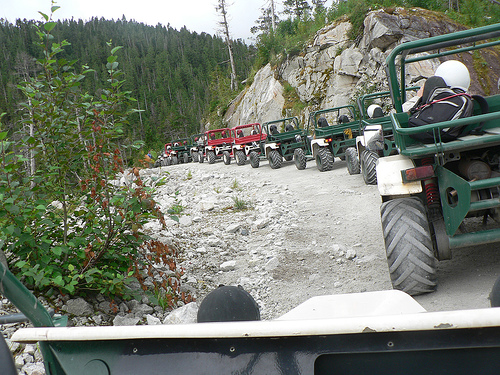

In [9]:
sample_ = dataset.sample()
path_, caption_ = sample_['image'].item(), sample_['caption'].item()

print(f"Caption: {caption_}")
Image.open(f"flickr8k/Images/{path_}")

Caption: A young girl making a wide mouthed expression while swinging .


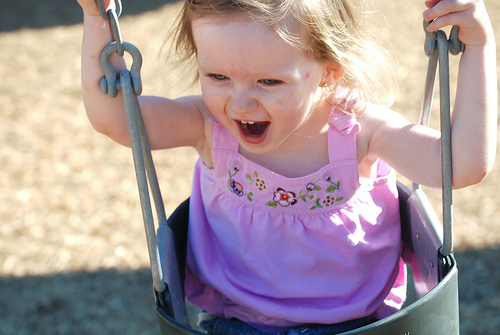

In [11]:
sample_ = dataset.sample()
path_, caption_ = sample_['image'].item(), sample_['caption'].item()

print(f"Caption: {caption_}")
Image.open(f"flickr8k/Images/{path_}")

## CLIP ViT Base - Testing

CLIP (Contrastive Language–Image Pretraining) embeddings map images and text into a shared semantic vector space, enabling cross-modal understanding. They allow tasks like text-to-image retrieval and image-to-text retrieval by comparing similarity between image and text vectors.

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [ ]:
sample_ = dataset.sample()
path_, caption_ = sample_['image'].item(), sample_['caption'].item()

image = Image.open(f"flickr8k/Images/{path_}")
texts = caption_

inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = model(**inputs)
    image_embeds = outputs.image_embeds  
    text_embeds = outputs.text_embeds    

## FAISS
FAISS (Facebook AI Similarity Search) is a library for efficient similarity search and clustering of dense vectors, enabling fast retrieval of nearest neighbors in large-scale datasets.

In [ ]:
embed_dims = 512

image_index = faiss.IndexFlatIP(embed_dims)
text_index = faiss.IndexFlatIP(embed_dims)

## Embedding Generation

### Images

In [ ]:
%%time
for pth in tqdm(dataset['image'].unique()):
    img_embed = get_text_embedding(f"flickr8k/Images/{pth}")
    norm_ = np.linalg.norm(img_embed)
    if norm_ > 0:
        img_embed = img_embed / norm_
    else:
        img_embed = img_embed

    img_embed = np.expand_dims(img_embed, axis=0)
    image_index.add(img_embed)

In [ ]:
faiss.write_index(image_index, "image_index.faiss")

### Text

In [ ]:
%%time
for txt in tqdm(dataset['caption'].unique()):
    txt_embed = get_text_embedding(txt)
    norm_ = np.linalg.norm(txt_embed)
    if norm_ > 0:
        txt_embed = txt_embed / norm_
    else:
        txt_embed = txt_embed

    txt_embed = np.expand_dims(txt_embed, axis=0)
    text_index.add(txt_embed)

In [ ]:
faiss.write_index(text_index, "text_index.faiss")

## Search

In [ ]:
image_index = faiss.read_index("image_index.faiss")
text_index = faiss.read_index("text_index.faiss")

In [ ]:
query_txt = get_text_embedding("Snow over mountains")
norm_ = np.linalg.norm(query_txt)
if norm_ > 0:
    query_txt = query_txt / norm_
else:
    query_txt = query_txt

query_txt = np.expand_dims(query_txt, axis=0)


distances, indices = image_index.search(query_txt, 5)

querypath_ = dataset["image"].unique()[indices[0][1]]
Image.open(f"flickr8k/Images/{querypath_}")

## Clustering

### Images

In [17]:
index = faiss.read_index("image_index.faiss")

n = index.ntotal
d = index.d

vectors = np.zeros((n, d), dtype='float32')

for i in range(n):
    vectors[i] = index.reconstruct(i)

print("Shape:", vectors.shape)

Shape: (8091, 512)


#### Using PCA and UMAP

In [18]:
pca_50 = PCA(n_components=50)
vec_50 = pca_50.fit_transform(vectors)

try:
    import umap
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=42)
    vec_2d = reducer.fit_transform(vec_50)
except ImportError:
    print("UMAP not installed — falling back to PCA(2).")
    vec_2d = PCA(n_components=2).fit_transform(vec_50)

/Users/asutoshdalei/Desktop/Work/solar/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Visualization

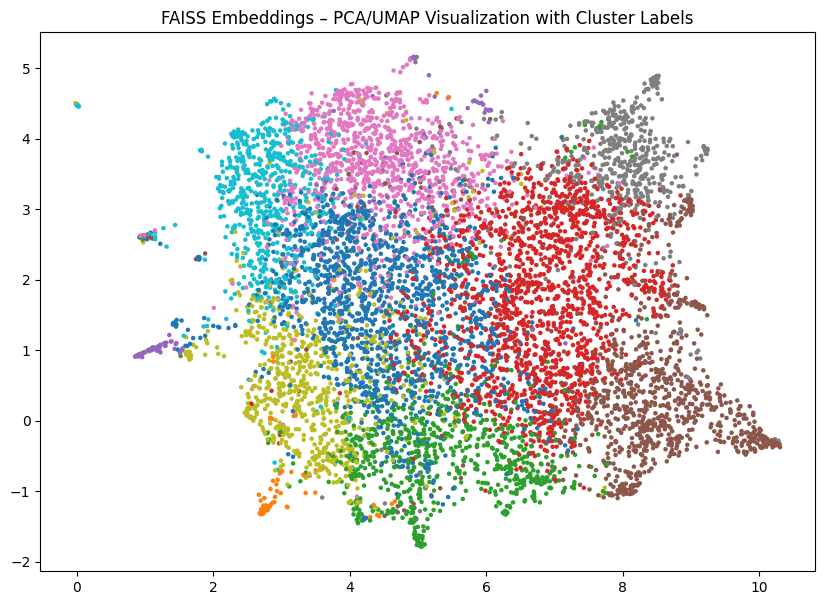

In [19]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(vec_50)

plt.figure(figsize=(10, 7))
plt.scatter(vec_2d[:, 0], vec_2d[:, 1], c=labels, s=5, cmap="tab10")
plt.title("FAISS Embeddings – PCA/UMAP Visualization with Cluster Labels")
plt.show()